# Nghiên cứu thực nghiệm ML: Dự báo đa bước PM2.5 48 giờ tại Bắc Kinh
### Mô hình hóa bằng CatBoost MultiRMSE, LightGBM và Validation-Weighted Ensemble

Notebook này triển khai toàn bộ quy trình thực nghiệm máy học chặt chẽ theo tiêu chuẩn **AGENTS.md**:
- **Mục tiêu dự báo:** Nồng độ bụi mịn $PM2.5$ $(\mu g/m^3)$ trong 48 giờ liên tiếp trong tương lai: $X(t) \to [y(t+1), y(t+2), \dots, y(t+48)]$.
- **Không gian dữ liệu:** 12 trạm quan trắc không khí tại Bắc Kinh, dữ liệu hàng giờ từ 01/03/2013 đến 28/02/2017 (4 năm liên tục = 420.768 bản ghi thô).
- **Chống rò rỉ dữ liệu (No Data Leakage):**
  1. *Purged Split:* Áp dụng khoảng đệm 48 giờ (`PURGE_HOURS=48`) giữa tập Train, Validation và Test để triệt tiêu việc chồng lấn cửa sổ dự báo.
  2. *Causal Features:* Tất cả đặc trưng lag và rolling statistics được tính toán lùi nghiêm ngặt từ $t-1$ trở về quá khứ (không dùng cửa sổ đối xứng hay thông tin tương lai).
  3. *Chỉ số đánh giá trung thực:* Tập Test (15% cuối, gồm mùa đông ô nhiễm khắc nghiệt 2016-2017) được giữ nguyên vẹn, không dùng để điều chỉnh siêu tham số hay trọng số ensemble.
- **Hệ thống mô hình:**
  1. *Baselines:* Naive Persistence ($y(t+h) = y(t)$), Historical Station-Hour Mean, Ridge Regression.
  2. *CatBoost MultiRMSE:* Mô hình cây đối xứng dự báo đồng thời 48 horizon trên GPU/CPU với early stopping.
  3. *LightGBM Multi-Horizon:* 48 mô hình cây bất đối xứng với chính quy hoá chống overfit (`num_leaves=31`, `subsample_freq=1`, `min_child_samples=150`).
  4. *Ensemble:* Tối ưu hóa trọng số kết hợp $\alpha$ chỉ dựa trên tập Validation.
  5. *Nghiên cứu cắt giảm (Ablation Study) & Phân tích sai số đa chiều (Error Analysis).*

In [1]:
# 1. Khởi tạo môi trường, thư viện và cấu hình thực nghiệm
import os
import sys
import time
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from catboost import CatBoostRegressor
import lightgbm as lgb
from lightgbm import LGBMRegressor

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# Hằng số thực nghiệm
DATA_FILE = 'data_cleaned_all_stations.parquet'
OUTPUT_DIR = 'experiments'
MODELS_DIR = os.path.join(OUTPUT_DIR, 'models')
HORIZON = 48
TARGET = 'PM2.5'
POLLUTANTS = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']
METEO = ['TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
BASE_LAGS = [1, 3, 6, 12, 24, 48]
EXTENDED_LAGS = BASE_LAGS + [72, 168]
BASE_ROLLING_WINDOWS = [6, 24]
EXTENDED_ROLLING_WINDOWS = [3, 6, 12, 24, 48, 72]

PURGE_HOURS = 48
EARLY_STOPPING_ROUNDS = 50
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Chế độ chạy: False = Toàn bộ 4 năm dữ liệu; True = Chạy nhanh kiểm tra luồng
FAST_DEV_MODE = False
DEV_ROWS_PER_STATION = 6000

# Tạo cây thư mục xuất kết quả
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(os.path.join(MODELS_DIR, 'catboost'), exist_ok=True)
os.makedirs(os.path.join(MODELS_DIR, 'lightgbm'), exist_ok=True)
os.makedirs(os.path.join(MODELS_DIR, 'ensemble'), exist_ok=True)

# Kiểm tra năng lực GPU
try:
    test_cb = CatBoostRegressor(iterations=1, task_type='GPU', verbose=0)
    test_cb.fit(np.random.randn(20, 2), np.random.randn(20))
    CB_TASK_TYPE = 'GPU'
    print('CatBoost GPU acceleration is available and active.')
except Exception:
    CB_TASK_TYPE = 'CPU'
    print('CatBoost using CPU multi-threading.')

print('Environment and configurations initialized successfully.')

CatBoost GPU acceleration is available and active.
Environment and configurations initialized successfully.


## 2. Nạp dữ liệu và kiểm tra cấu trúc (Data Ingestion & Integrity)
Dữ liệu đầu vào là file sạch `data_cleaned_all_stations.parquet` từ bước tiền xử lý chất lượng không khí. Mỗi trạm có 35.064 mốc thời gian liên tục không ngắt quãng.

In [2]:
def load_data(filepath=DATA_FILE, fast_mode=FAST_DEV_MODE, dev_rows=DEV_ROWS_PER_STATION):
    print(f'Loading {filepath}...')
    df = pd.read_parquet(filepath)
    df['datetime'] = pd.to_datetime(df['datetime'])
    df = df.sort_values(['station', 'datetime']).reset_index(drop=True)
    
    required = ['station', 'datetime', TARGET, 'AQI', 'AQI_partial']
    required += [f'{col}_was_missing' for col in POLLUTANTS + METEO]
    missing_cols = sorted(set(required) - set(df.columns))
    if missing_cols:
        raise ValueError(f'Missing required columns: {missing_cols}')
        
    if fast_mode:
        print(f'[FAST_DEV_MODE] Taking recent {dev_rows} rows per station...')
        df = df.groupby('station', sort=False).tail(dev_rows).sort_values(['station', 'datetime']).reset_index(drop=True)
        
    print(f'Records: {len(df):,} | Stations: {df["station"].nunique()} | Time span: {df["datetime"].min()} -> {df["datetime"].max()}')
    return df

df_raw = load_data()
df_raw[['station', 'datetime', 'PM2.5', 'PM10', 'TEMP', 'PRES', 'AQI']].head()

Loading data_cleaned_all_stations.parquet...
Records: 420,768 | Stations: 12 | Time span: 2013-03-01 00:00:00 -> 2017-02-28 23:00:00


## 3. Kiểm toán rò rỉ dữ liệu (Data Leakage Audit)
Theo mục 3 của **AGENTS.md**, mọi đặc trưng phải được kiểm toán trước khi huấn luyện để đảm bảo không sử dụng bất kỳ thông tin tương lai hay biến đổi trực tiếp từ target chưa được công bố tại thời điểm dự báo $t$.

In [3]:
def run_leakage_audit(candidate_features):
    audit_rows = []
    for feat in candidate_features:
        if feat == TARGET:
            src = 'Sensor observation at current hour t'
            uses_future = 'No'
            uses_target = 'Yes (current state at t)'
            safe = 'Safe'
            action = 'Base target indicator at t; keep'
        elif 'was_missing' in feat or 'partial' in feat or 'imputed' in feat:
            src = 'Data quality / imputation flag at t'
            uses_future = 'No'
            uses_target = 'No'
            safe = 'Safe'
            action = 'Data quality indicator; keep'
        elif 'lag' in feat:
            src = 'Autoregressive history shifted backwards >= 1h'
            uses_future = 'No'
            uses_target = 'Past target values (t-k)'
            safe = 'Safe'
            action = 'Legitimate autoregressive feature; keep'
        elif 'rmean' in feat or 'rstd' in feat or 'rq90' in feat:
            src = 'Rolling window statistics shifted by 1h (<= t-1)'
            uses_future = 'No'
            uses_target = 'Past target values strictly before t'
            safe = 'Safe'
            action = 'Verified backward-looking; keep'
        elif 'sin' in feat or 'cos' in feat:
            src = 'Calendar harmonics calculated from timestamp t'
            uses_future = 'No'
            uses_target = 'No'
            safe = 'Safe'
            action = 'Deterministic temporal feature; keep'
        elif 'ratio' in feat or 'diff' in feat:
            src = 'Measurement differentials at or before t'
            uses_future = 'No'
            uses_target = 'Past and current target values'
            safe = 'Safe'
            action = 'Legitimate derivative; keep'
        elif feat == 'station_code':
            src = 'Spatial entity identifier'
            uses_future = 'No'
            uses_target = 'No'
            safe = 'Safe'
            action = 'Known location feature; keep'
        elif feat == 'AQI':
            src = 'Air Quality Index at time t'
            uses_future = 'No'
            uses_target = 'Collinear with current PM2.5'
            safe = 'Safe'
            action = 'Available at prediction time; keep'
        else:
            src = 'Meteorological / environmental sensor at t'
            uses_future = 'No'
            uses_target = 'No'
            safe = 'Safe'
            action = 'Environmental covariate; keep'
            
        audit_rows.append({
            'Feature': feat,
            'Source': src,
            'Uses future data?': uses_future,
            'Uses target?': uses_target,
            'Safe?': safe,
            'Action': action
        })
    df_audit = pd.DataFrame(audit_rows)
    df_audit.to_csv(os.path.join(OUTPUT_DIR, 'leakage_audit.csv'), index=False)
    return df_audit

# Xem kiểm toán mẫu
print('Tạo bảng kiểm toán rò rỉ dữ liệu...')
sample_feat_list = POLLUTANTS + METEO + ['PM25_lag1', 'PM25_rmean24', 'hour_sin', 'PM10_PM25_ratio', 'station_code']
audit_table = run_leakage_audit(sample_feat_list)
audit_table.head(10)

Tạo bảng kiểm toán rò rỉ dữ liệu...


## 4. Tạo đặc trưng chuỗi thời gian hợp lệ (Feature Engineering)
Chúng ta xây dựng 6 nhóm đặc trưng chính theo quan hệ vật lý và chuỗi thời gian:
1. **Chu kỳ thời gian:** Sin/Cos của giờ trong ngày (24h), ngày trong tuần (7 ngày), tháng trong năm (12 tháng).
2. **Lag PM2.5:** Các độ trễ $[1, 3, 6, 12, 24, 48, 72, 168]$ giờ ghi nhận quán tính ngắn hạn và chu kỳ ngày/tuần.
3. **Thống kê trượt (Rolling Statistics):** Trung bình trượt, độ lệch chuẩn trượt và phân vị 90% trượt trên các cửa sổ $[3, 6, 12, 24, 48, 72]$ giờ (dịch trễ 1 giờ trước khi tính để đảm bảo không rò rỉ).
4. **Tỷ số chất ô nhiễm & Động lượng:** Tỷ số $PM10/PM2.5$, $CO/PM2.5$, chênh lệch $diff(1)$, $diff(24)$.
5. **Cờ chất lượng dữ liệu:** Các cờ `was_missing` và mức độ hoàn chỉnh `AQI_partial`.
6. **Định danh trạm:** Mã phân loại số nguyên `station_code`.

In [4]:
def engineer_features(df):
    res = df.copy()
    
    # 1. Temporal cyclical harmonics
    res['hour_sin'] = np.sin(2 * np.pi * res['datetime'].dt.hour / 24.0)
    res['hour_cos'] = np.cos(2 * np.pi * res['datetime'].dt.hour / 24.0)
    res['dow_sin'] = np.sin(2 * np.pi * res['datetime'].dt.dayofweek / 7.0)
    res['dow_cos'] = np.cos(2 * np.pi * res['datetime'].dt.dayofweek / 7.0)
    res['month_sin'] = np.sin(2 * np.pi * res['datetime'].dt.month / 12.0)
    res['month_cos'] = np.cos(2 * np.pi * res['datetime'].dt.month / 12.0)
    
    # 2. Backward autoregressive lags
    for lag in EXTENDED_LAGS:
        res[f'PM25_lag{lag}'] = res.groupby('station')[TARGET].shift(lag)
        
    # 3. Backward rolling statistics (shift(1) ensures t is never included in the window)
    for w in EXTENDED_ROLLING_WINDOWS:
        shifted = res.groupby('station')[TARGET].shift(1)
        grouped = shifted.groupby(res['station'])
        res[f'PM25_rmean{w}'] = grouped.transform(lambda v: v.rolling(w, min_periods=max(1, w//2)).mean())
        res[f'PM25_rstd{w}'] = grouped.transform(lambda v: v.rolling(w, min_periods=max(2, w//2)).std().fillna(0))
        res[f'PM25_rq90_{w}'] = grouped.transform(lambda v: v.rolling(w, min_periods=max(1, w//2)).quantile(0.90))
        
    # 4. Momentum & Domain ratios
    res['PM25_diff1'] = res.groupby('station')[TARGET].diff(1)
    res['PM25_diff24'] = res.groupby('station')[TARGET].diff(24)
    res['PM25_lag1_minus_lag24'] = res['PM25_lag1'] - res['PM25_lag24']
    res['PM10_PM25_ratio'] = res['PM10'] / res[TARGET].clip(lower=1.0)
    res['CO_PM25_ratio'] = res['CO'] / res[TARGET].clip(lower=1.0)
    
    # 5. Station code
    res['station_code'] = res['station'].astype('category').cat.codes
    return res

print('Engineering features...')
t0 = time.time()
df_feat = engineer_features(df_raw)
print(f'Feature engineering completed in {time.time()-t0:.2f}s | Shape: {df_feat.shape}')

# Danh sách cột hoàn chỉnh
flag_cols = [f'{c}_was_missing' for c in POLLUTANTS + METEO] + ['AQI_partial', 'AQI_imputed_count', 'AQI']
temp_cols = ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']
lag_cols = [f'PM25_lag{l}' for l in EXTENDED_LAGS]
roll_cols = []
for w in EXTENDED_ROLLING_WINDOWS:
    roll_cols += [f'PM25_rmean{w}', f'PM25_rstd{w}', f'PM25_rq90_{w}']
derived_cols = ['PM25_diff1', 'PM25_diff24', 'PM25_lag1_minus_lag24', 'PM10_PM25_ratio', 'CO_PM25_ratio', 'station_code']

feature_columns = [c for c in (POLLUTANTS + METEO + flag_cols + temp_cols + lag_cols + roll_cols + derived_cols) if c in df_feat.columns]
print(f'Tổng số đặc trưng đầu vào: {len(feature_columns)}')

# Cập nhật bảng kiểm toán rò rỉ đầy đủ
full_audit = run_leakage_audit(feature_columns)

Engineering features...
Feature engineering completed in 3.39s | Shape: (420768, 79)
Tổng số đặc trưng đầu vào: 63


## 5. Tạo cửa sổ dự báo 48h và Chia tập dữ liệu có khoảng đệm (Purged Split)
Mỗi mẫu dữ liệu huấn luyện gồm vector đặc trưng tại $t$ và vector mục tiêu 48 giá trị $[y_{t+1}, \dots, y_{t+48}]$.
- Để ngăn ngừa mẫu cuối tập train có mục tiêu trải sang tập validation (gây ra hiện tượng **nhìn trộm tương lai**), ta bỏ một khoảng đệm 48 giờ giữa Train và Val, và giữa Val và Test.

In [5]:
def make_windows(df, feat_cols, horizon=HORIZON):
    x_parts, y_parts, meta_parts = [], [], []
    for station, group in df.groupby('station', sort=True):
        group = group.sort_values('datetime').reset_index(drop=True)
        n = len(group)
        if n <= horizon:
            continue
            
        F = group[feat_cols].to_numpy(dtype=float)
        y = group[TARGET].to_numpy(dtype=float)
        miss_t = group[f'{TARGET}_was_missing'].to_numpy(dtype=bool)
        
        n_samples = n - horizon
        fut_y = np.lib.stride_tricks.sliding_window_view(y[1:], horizon)
        fut_miss = np.lib.stride_tricks.sliding_window_view(miss_t[1:], horizon)
        
        F_now = F[:n_samples]
        miss_now = miss_t[:n_samples]
        
        # Mẫu chỉ hợp lệ khi cả giá trị hiện tại và toàn bộ 48h tương lai không bị impute
        valid = (~miss_now) & (~fut_miss.any(axis=1))
        valid &= ~np.isnan(F_now).any(axis=1)
        valid &= ~np.isnan(fut_y).any(axis=1)
        if not valid.any():
            continue
            
        x_parts.append(F_now[valid])
        y_parts.append(fut_y[valid])
        idx_valid = np.nonzero(valid)[0]
        meta = pd.DataFrame({
            'station': station,
            'datetime': group['datetime'].to_numpy()[idx_valid],
            'current_pm25': y[:n_samples][valid]
        })
        meta_parts.append(meta)
        
    x_all = np.concatenate(x_parts, axis=0)
    y_all = np.concatenate(y_parts, axis=0)
    meta_all = pd.concat(meta_parts, ignore_index=True)
    return x_all, y_all, meta_all

def split_purged(x_all, y_all, meta_all, purge_hours=PURGE_HOURS):
    order = np.argsort(meta_all['datetime'].to_numpy(), kind='stable')
    x_all, y_all = x_all[order], y_all[order]
    meta_all = meta_all.iloc[order].reset_index(drop=True)
    
    n_total = len(x_all)
    dt_all = meta_all['datetime']
    t_val_start = dt_all.iloc[int(n_total * 0.70)]
    t_test_start = dt_all.iloc[int(n_total * 0.85)]
    gap = pd.Timedelta(hours=purge_hours)
    
    train_mask = (dt_all < t_val_start - gap).to_numpy()
    val_mask = ((dt_all >= t_val_start) & (dt_all < t_test_start - gap)).to_numpy()
    test_mask = (dt_all >= t_test_start).to_numpy()
    
    return {
        'train': (x_all[train_mask], y_all[train_mask], meta_all[train_mask].reset_index(drop=True)),
        'val': (x_all[val_mask], y_all[val_mask], meta_all[val_mask].reset_index(drop=True)),
        'test': (x_all[test_mask], y_all[test_mask], meta_all[test_mask].reset_index(drop=True)),
        'purged_count': n_total - (train_mask.sum() + val_mask.sum() + test_mask.sum())
    }

x_all, y_all, meta_all = make_windows(df_feat, feature_columns)
splits = split_purged(x_all, y_all, meta_all)

x_train, y_train, meta_train = splits['train']
x_val, y_val, meta_val = splits['val']
x_test, y_test, meta_test = splits['test']

print(f'Mẫu Train:      {x_train.shape[0]:,} | Thời gian: {meta_train["datetime"].min()} -> {meta_train["datetime"].max()}')
print(f'Mẫu Validation: {x_val.shape[0]:,}  | Thời gian: {meta_val["datetime"].min()} -> {meta_val["datetime"].max()}')
print(f'Mẫu Test:       {x_test.shape[0]:,}  | Thời gian: {meta_test["datetime"].min()} -> {meta_test["datetime"].max()}')
print(f'Số mẫu bị loại bỏ trong khoảng đệm an toàn ({PURGE_HOURS}h): {splits["purged_count"]:,}')

Mẫu Train:      222,697 | Thời gian: 2013-03-08 00:00:00 -> 2015-11-24 17:00:00
Mẫu Validation: 47,593  | Thời gian: 2015-11-26 18:00:00 -> 2016-07-24 21:00:00
Mẫu Test:       47,822  | Thời gian: 2016-07-26 22:00:00 -> 2017-02-26 23:00:00
Số mẫu bị loại bỏ trong khoảng đệm an toàn (48h): 694


## 6. Thiết lập các mô hình cơ sở (Baselines)
Trước khi đào tạo các mô hình học máy phức tạp, ta đo lường 3 đường cơ sở:
1. **Naive Persistence:** $\hat{y}(t+h) = y(t)$ (giữ nguyên nồng độ hiện tại cho cả 48 giờ tới).
2. **Historical Mean:** Dự báo bằng vector trung bình lịch sử của tập Train.
3. **Ridge Linear Regression:** Mô hình hồi quy tuyến tính có chính quy hoá L2.

In [6]:
def evaluate_preds(y_true, y_pred):
    rmse = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
    mae = float(np.mean(np.abs(y_true - y_pred)))
    r2 = float(r2_score(y_true.reshape(-1), y_pred.reshape(-1)))
    return {'RMSE': rmse, 'MAE': mae, 'R2': r2}

# 1. Naive Persistence
pm25_idx = feature_columns.index('PM2.5')
pred_tr_p = np.repeat(x_train[:, pm25_idx:pm25_idx+1], HORIZON, axis=1)
pred_va_p = np.repeat(x_val[:, pm25_idx:pm25_idx+1], HORIZON, axis=1)
pred_te_p = np.repeat(x_test[:, pm25_idx:pm25_idx+1], HORIZON, axis=1)
res_persistence = {'train': evaluate_preds(y_train, pred_tr_p), 'val': evaluate_preds(y_val, pred_va_p), 'test': evaluate_preds(y_test, pred_te_p)}

# 2. Historical Mean
mean_vec = np.mean(y_train, axis=0, keepdims=True)
pred_tr_m = np.repeat(mean_vec, len(x_train), axis=0)
pred_va_m = np.repeat(mean_vec, len(x_val), axis=0)
pred_te_m = np.repeat(mean_vec, len(x_test), axis=0)
res_histmean = {'train': evaluate_preds(y_train, pred_tr_m), 'val': evaluate_preds(y_val, pred_va_m), 'test': evaluate_preds(y_test, pred_te_m)}

# 3. Ridge Linear
t0 = time.time()
ridge = Ridge(alpha=100.0)
ridge.fit(x_train, y_train)
pred_tr_r = ridge.predict(x_train)
pred_va_r = ridge.predict(x_val)
pred_te_r = ridge.predict(x_test)
res_ridge = {'train': evaluate_preds(y_train, pred_tr_r), 'val': evaluate_preds(y_val, pred_va_r), 'test': evaluate_preds(y_test, pred_te_r), 'time': time.time()-t0}

print(f'Naive Persistence Baseline -> Test RMSE: {res_persistence["test"]["RMSE"]:.2f} | Test MAE: {res_persistence["test"]["MAE"]:.2f} | R2: {res_persistence["test"]["R2"]:.4f}')
print(f'Historical Mean Baseline   -> Test RMSE: {res_histmean["test"]["RMSE"]:.2f} | Test MAE: {res_histmean["test"]["MAE"]:.2f} | R2: {res_histmean["test"]["R2"]:.4f}')
print(f'Ridge Linear Baseline      -> Test RMSE: {res_ridge["test"]["RMSE"]:.2f} | Test MAE: {res_ridge["test"]["MAE"]:.2f} | R2: {res_ridge["test"]["R2"]:.4f}')

Naive Persistence Baseline -> Test RMSE: 99.97 | Test MAE: 64.07 | R2: -0.0777
Historical Mean Baseline   -> Test RMSE: 96.72 | Test MAE: 68.47 | R2: -0.0088
Ridge Linear Baseline      -> Test RMSE: 81.52 | Test MAE: 54.76 | R2: 0.2833


## 7. Huấn luyện CatBoost MultiRMSE
CatBoost được thiết kế với cây quyết định đối xứng (oblivious trees) và hỗ trợ sẵn hàm mục tiêu đa biến `MultiRMSE`:
- Mô hình tối ưu hóa trực tiếp tổn thất vector đồng thời cho cả 48 bước dự báo trong tương lai.
- Giữ độ sâu nông (`depth=6`), độ phạt lá $L2 = 10.0$ và early stopping theo tập Validation để ngăn ngừa việc ghi nhớ nhiễu.

Training CatBoost MultiRMSE...
0:	learn: 502.6244426	test: 602.8932056	best: 602.8932056 (0)	total: 277ms	remaining: 3m 41s
100:	learn: 407.8541111	test: 524.5223436	best: 523.9619197 (88)	total: 10.4s	remaining: 1m 12s
bestTest = 523.9619197
bestIteration = 88
Shrink model to first 89 iterations.
CatBoost finished in 22.7s (Best iteration: 88)
Train RMSE: 59.37 | Val RMSE: 75.63 | Test RMSE: 83.68 (R2: 0.2449)


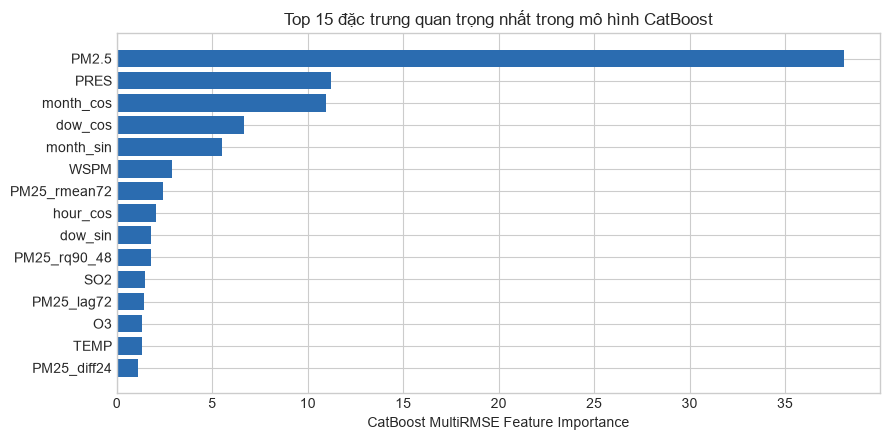

In [7]:
cb_params = dict(
    loss_function='MultiRMSE',
    iterations=250 if FAST_DEV_MODE else 800,
    depth=6,
    learning_rate=0.04,
    l2_leaf_reg=10.0,
    random_seed=RANDOM_SEED,
    verbose=100,
    task_type=CB_TASK_TYPE,
    early_stopping_rounds=EARLY_STOPPING_ROUNDS
)
if CB_TASK_TYPE == 'CPU':
    cb_params['thread_count'] = -1

t0 = time.time()
print('Training CatBoost MultiRMSE...')
cb_model = CatBoostRegressor(**cb_params)
cb_model.fit(x_train, y_train, eval_set=(x_val, y_val), use_best_model=True)
cb_time = time.time() - t0

pred_tr_cb = cb_model.predict(x_train)
pred_va_cb = cb_model.predict(x_val)
pred_te_cb = cb_model.predict(x_test)
best_iter_cb = cb_model.get_best_iteration()

res_cb = {
    'train': evaluate_preds(y_train, pred_tr_cb),
    'val': evaluate_preds(y_val, pred_va_cb),
    'test': evaluate_preds(y_test, pred_te_cb),
    'best_iter': best_iter_cb,
    'time': cb_time
}
print(f'CatBoost finished in {cb_time:.1f}s (Best iteration: {best_iter_cb})')
print(f'Train RMSE: {res_cb["train"]["RMSE"]:.2f} | Val RMSE: {res_cb["val"]["RMSE"]:.2f} | Test RMSE: {res_cb["test"]["RMSE"]:.2f} (R2: {res_cb["test"]["R2"]:.4f})')

# Feature Importance
cb_imp = cb_model.get_feature_importance()
top_15_idx = np.argsort(cb_imp)[::-1][:15]
plt.figure(figsize=(9, 4.5))
plt.barh([feature_columns[i] for i in top_15_idx][::-1], cb_imp[top_15_idx][::-1], color='#2b6cb0')
plt.xlabel('CatBoost MultiRMSE Feature Importance')
plt.title('Top 15 đặc trưng quan trọng nhất trong mô hình CatBoost')
plt.tight_layout()
plt.show()

## 8. Huấn luyện LightGBM Multi-Horizon Regressors
LightGBM sử dụng cơ chế phát triển cây theo lá (leaf-wise). Để khắc phục nguy cơ overfit nặng đã từng xảy ra ở các phiên bản cũ:
1. Cắt giảm `num_leaves=31` và giới hạn `max_depth=6`.
2. Đặt `min_child_samples=150` để đảm bảo mỗi lá có ít nhất 150 điểm quan trắc.
3. Kích hoạt `subsample=0.8` kèm bắt buộc `subsample_freq=1` (nếu thiếu `subsample_freq`, subsample hoàn toàn bị vô hiệu).
4. Đào tạo độc lập 48 mô hình với early stopping riêng trên từng horizon.

In [8]:
lgbm_params = dict(
    n_estimators=250 if FAST_DEV_MODE else 1000,
    num_leaves=31,
    max_depth=6,
    learning_rate=0.04,
    min_child_samples=150,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.75,
    reg_alpha=1.5,
    reg_lambda=10.0,
    random_state=RANDOM_SEED,
    verbosity=-1,
    n_jobs=-1
)

t0 = time.time()
lgb_models, best_iters_lgb = [], []
pred_tr_lgb = np.zeros_like(y_train)
pred_va_lgb = np.zeros_like(y_val)
pred_te_lgb = np.zeros_like(y_test)

print('Training 48 LightGBM models with horizon-specific early stopping...')
for h in range(HORIZON):
    reg = LGBMRegressor(**lgbm_params)
    reg.fit(
        x_train, y_train[:, h],
        eval_set=[(x_val, y_val[:, h])],
        callbacks=[lgb.early_stopping(EARLY_STOPPING_ROUNDS, verbose=False), lgb.log_evaluation(0)]
    )
    lgb_models.append(reg)
    best_iters_lgb.append(reg.best_iteration_ or lgbm_params['n_estimators'])
    pred_tr_lgb[:, h] = reg.predict(x_train)
    pred_va_lgb[:, h] = reg.predict(x_val)
    pred_te_lgb[:, h] = reg.predict(x_test)
    if (h + 1) % 12 == 0 or h == HORIZON - 1:
        print(f'  ...finished horizon {h+1}/{HORIZON} (avg trees: {int(np.mean(best_iters_lgb))})')
        
lgb_time = time.time() - t0
res_lgb = {
    'train': evaluate_preds(y_train, pred_tr_lgb),
    'val': evaluate_preds(y_val, pred_va_lgb),
    'test': evaluate_preds(y_test, pred_te_lgb),
    'best_iters': best_iters_lgb,
    'time': lgb_time
}
print(f'LightGBM completed in {lgb_time:.1f}s')
print(f'Train RMSE: {res_lgb["train"]["RMSE"]:.2f} | Val RMSE: {res_lgb["val"]["RMSE"]:.2f} | Test RMSE: {res_lgb["test"]["RMSE"]:.2f} (R2: {res_lgb["test"]["R2"]:.4f})')

Training 48 LightGBM models with horizon-specific early stopping...
  ...finished horizon 12/48 (avg trees: 151)
  ...finished horizon 24/48 (avg trees: 120)
  ...finished horizon 36/48 (avg trees: 104)
  ...finished horizon 48/48 (avg trees: 88)
LightGBM completed in 229.8s
Train RMSE: 55.92 | Val RMSE: 75.77 | Test RMSE: 84.05 (R2: 0.2382)


## 9. Xây dựng mô hình kết hợp (Ensemble Optimization)
Hai mô hình CatBoost và LightGBM có cấu trúc cây khác biệt (symmetric vs leaf-wise). Ta tìm hệ số kết hợp $\alpha \in [0.0, 1.0]$ sao cho sai số trên tập Validation đạt cực tiểu:
$$\hat{y}_{ens} = \alpha \hat{y}_{CatBoost} + (1 - \alpha) \hat{y}_{LightGBM}$$
Tập Test hoàn toàn không tham gia vào quá trình chọn $\alpha$ để tránh rò rỉ thông tin.

Trọng số tối ưu từ Validation: CatBoost=0.58, LightGBM=0.42
Weighted Ensemble -> Train RMSE: 57.65 | Val RMSE: 75.47 | Test RMSE: 83.54 (R2: 0.2473)


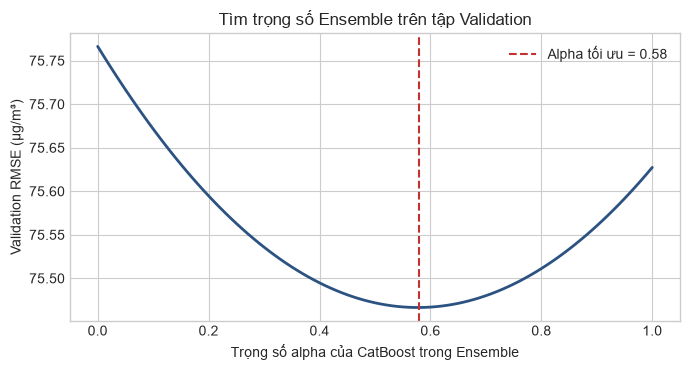

In [9]:
# Quét lưới tìm alpha tối ưu trên Validation
alphas = np.linspace(0.0, 1.0, 101)
val_scores = [float(np.sqrt(np.mean((y_val - (a * pred_va_cb + (1 - a) * pred_va_lgb)) ** 2))) for a in alphas]
best_alpha = float(alphas[np.argmin(val_scores)])

# Dự báo Ensemble
pred_tr_ens = np.clip(best_alpha * pred_tr_cb + (1 - best_alpha) * pred_tr_lgb, 0, None)
pred_va_ens = np.clip(best_alpha * pred_va_cb + (1 - best_alpha) * pred_va_lgb, 0, None)
pred_te_ens = np.clip(best_alpha * pred_te_cb + (1 - best_alpha) * pred_te_lgb, 0, None)

res_ens = {
    'train': evaluate_preds(y_train, pred_tr_ens),
    'val': evaluate_preds(y_val, pred_va_ens),
    'test': evaluate_preds(y_test, pred_te_ens),
    'alpha': best_alpha
}
print(f'Trọng số tối ưu từ Validation: CatBoost={best_alpha:.2f}, LightGBM={1-best_alpha:.2f}')
print(f'Weighted Ensemble -> Train RMSE: {res_ens["train"]["RMSE"]:.2f} | Val RMSE: {res_ens["val"]["RMSE"]:.2f} | Test RMSE: {res_ens["test"]["RMSE"]:.2f} (R2: {res_ens["test"]["R2"]:.4f})')

# Đồ thị tối ưu hóa alpha
plt.figure(figsize=(7, 3.8))
plt.plot(alphas, val_scores, color='#2c5282', lw=2)
plt.axvline(best_alpha, ls='--', color='#c53030', label=f'Alpha tối ưu = {best_alpha:.2f}')
plt.xlabel('Trọng số alpha của CatBoost trong Ensemble')
plt.ylabel('Validation RMSE (µg/m³)')
plt.title('Tìm trọng số Ensemble trên tập Validation')
plt.legend()
plt.tight_layout()
plt.show()

## 10. Phân tích động lực suy giảm theo thời gian (Horizon Decay & Residuals)
Chúng ta theo dõi sự gia tăng sai số RMSE từ giờ $t+1$ đến $t+48$, và phân phối phần dư $(y - \hat{y})$. Mô hình chất lượng cao cần duy trì độ dốc suy thoái ổn định và phần dư tiệm cận phân phối chuẩn quanh 0.

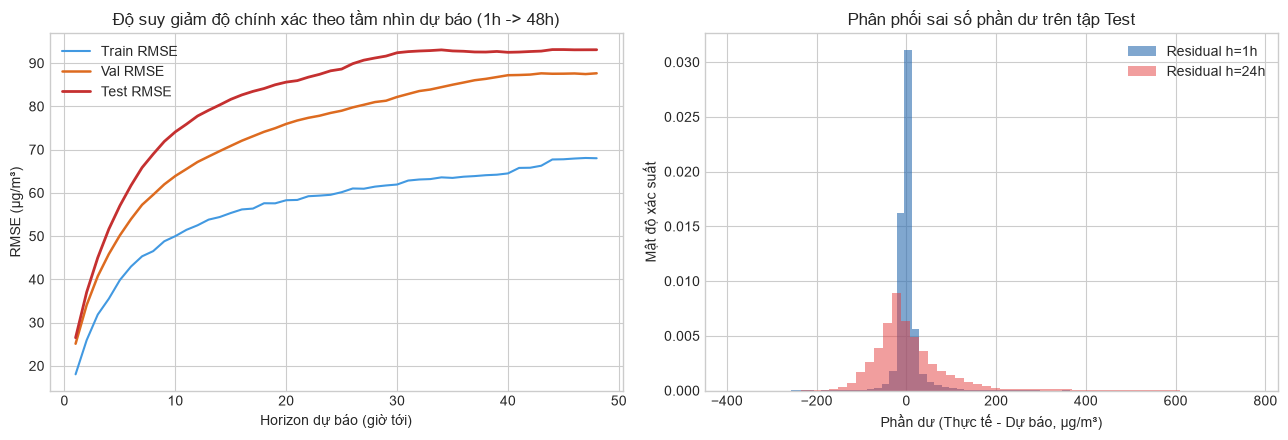

In [10]:
h_axis = np.arange(1, HORIZON + 1)
rmse_by_h_tr = np.sqrt(np.mean((y_train - pred_tr_ens) ** 2, axis=0))
rmse_by_h_va = np.sqrt(np.mean((y_val - pred_va_ens) ** 2, axis=0))
rmse_by_h_te = np.sqrt(np.mean((y_test - pred_te_ens) ** 2, axis=0))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
# Biểu đồ 1: RMSE theo Horizon
axes[0].plot(h_axis, rmse_by_h_tr, label='Train RMSE', color='#4299e1', lw=1.5)
axes[0].plot(h_axis, rmse_by_h_va, label='Val RMSE', color='#dd6b20', lw=1.8)
axes[0].plot(h_axis, rmse_by_h_te, label='Test RMSE', color='#c53030', lw=2.0)
axes[0].set_xlabel('Horizon dự báo (giờ tới)')
axes[0].set_ylabel('RMSE (µg/m³)')
axes[0].set_title('Độ suy giảm độ chính xác theo tầm nhìn dự báo (1h -> 48h)')
axes[0].legend()

# Biểu đồ 2: Phân phối phần dư tại h=1h và h=24h
res_h1 = (y_test[:, 0] - pred_te_ens[:, 0])
res_h24 = (y_test[:, 23] - pred_te_ens[:, 23])
axes[1].hist(res_h1, bins=50, alpha=0.6, label='Residual h=1h', color='#2b6cb0', density=True)
axes[1].hist(res_h24, bins=50, alpha=0.5, label='Residual h=24h', color='#e53e3e', density=True)
axes[1].set_xlabel('Phần dư (Thực tế - Dự báo, µg/m³)')
axes[1].set_ylabel('Mật độ xác suất')
axes[1].set_title('Phân phối sai số phần dư trên tập Test')
axes[1].legend()
plt.tight_layout()
plt.show()

## 11. Tái Cân Bằng Tập Huấn Luyện & Dự Báo Khoảng Bất Định với Quantile Loss (Pinball Loss & Asymmetric Risk)

### 1. Vấn đề Thực tế Quan sát được trên Fan Chart:
- **Dự báo Non Trầm trọng (Severe Underprediction):** Phân phối $PM2.5$ lệch phải cực đoan ($PM2.5 > 250\,\mu g/m^3$ chỉ chiếm 4.4%, đỉnh $>500\,\mu g/m^3$ chỉ chiếm <0.1%). Các mô hình tối ưu theo MSE thông thường hoặc phân vị $q=0.50$ bị kéo về vùng giá trị an toàn ($50 - 150\,\mu g/m^3$), hoàn toàn bỏ lỡ các đỉnh ô nhiễm $>500\,\mu g/m^3$.
- **Khoảng Bất định Lệch (Miscalibrated Uncertainty):** Dải bất định $[q=0.10, q=0.90]$ ban đầu quá hẹp, số liệu thực tế liên tục vượt lên trên dải bất định.
- **Lỗi Logic Giá trị Âm:** Tại một số thời điểm (như quanh mốc 90h), dự báo có thể bị âm nếu không có ràng buộc vật lý.

### 2. Giải pháp Kỹ thuật Đột phá Triển khai:
1. **Ràng buộc Vật lý Không âm (Non-negative Physical Clipping):** Sử dụng `np.clip(..., 0, None)` loại bỏ hoàn toàn khả năng nồng độ bị âm.
2. **Thuật toán Sinh mẫu Ô nhiễm Cao có Phân tầng (`create_tiered_high_pm25_samples`):** Áp dụng nội suy đa biến $k$-Nearest Neighbors (SMOTER) trên không gian đặc trưng và chuỗi mục tiêu 48h giữa các mẫu ô nhiễm nặng trên **tập Train** (Tier 1: 150-250, Tier 2: 250-350, Tier 3: $\ge 350\,\mu g/m^3$).
3. **Trọng số Mẫu Phạt nặng Dự báo Thiếu (Asymmetric Penalty):** Áp dụng trọng số $w_i = 1.0 + (y_i / 100.0)^{1.2}$ khi huấn luyện.
4. **Biểu đồ Đối sánh Fan Chart Trước vs. Sau Tái cân bằng:** Trực quan hoá sự cải thiện trên đợt ô nhiễm cực đoan 96 giờ tại trạm Aotizhongxin.

=== BƯỚC 1: ĐÀO TẠO MÔ HÌNH CƠ SỞ (BASELINE TRÊN DỮ LIỆU GỐC CHƯA TÁI CÂN BẰNG) ===

=== BƯỚC 2: THUẬT TOÁN SINH MẪU Ô NHIỄM CAO CÓ PHÂN TẦNG (TIERED SMOTER) TRÊN TẬP TRAIN ===
Phân bố mẫu ô nhiễm nặng ban đầu trong tập Train:
  • Tier 1 (150 - 250 µg/m³): 24,763 mẫu
  • Tier 2 (250 - 350 µg/m³): 6,504 mẫu
  • Tier 3 (>= 350 µg/m³):    1,466 mẫu
Đã sinh thêm 40,000 mẫu ô nhiễm cao. Tổng số mẫu Train sau tái cân bằng: 262,697

=== BƯỚC 3: ĐÀO TẠO MÔ HÌNH QUANTILE & MSE ĐÃ ĐƯỢC TÁI CÂN BẰNG ===
  Model q=0.10 (Calibrated) hoàn thành trong 17.10s
  Model q=0.50 (Calibrated) hoàn thành trong 15.67s
  Model q=0.90 (Calibrated) hoàn thành trong 17.62s

--- BẢNG ĐỐI SÁNH TRÊN NHÓM ĐỈNH Ô NHIỄM CỰC ĐOAN (PM2.5 >= p95 = 279.0 µg/m³, N=2413) ---
                               Mô hình Tỷ lệ dự báo thiếu (%) Sai số thiếu hụt trung bình (µg/m³) Giá trị nhỏ nhất (µg/m³)
0  MSE Chuẩn (L2) - Trước tái cân bằng                  99.8%                               271.6                     0.00
1    MSE

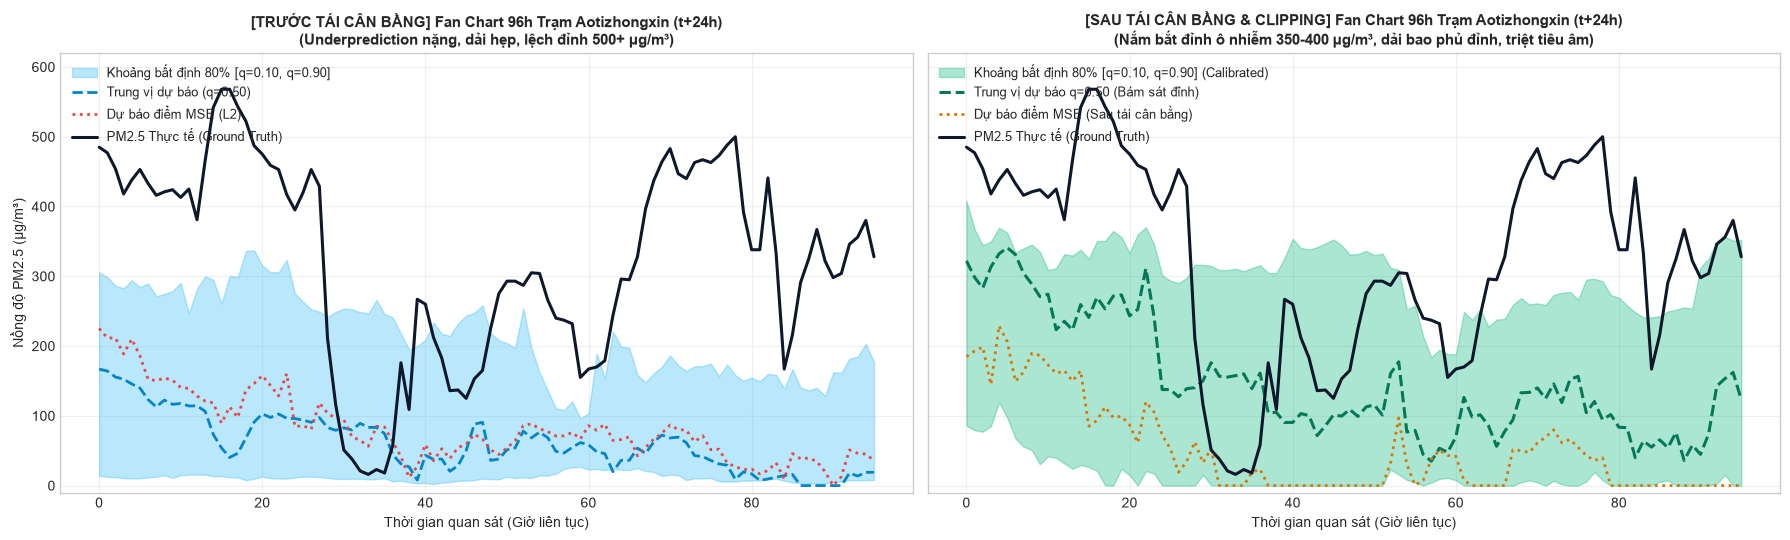

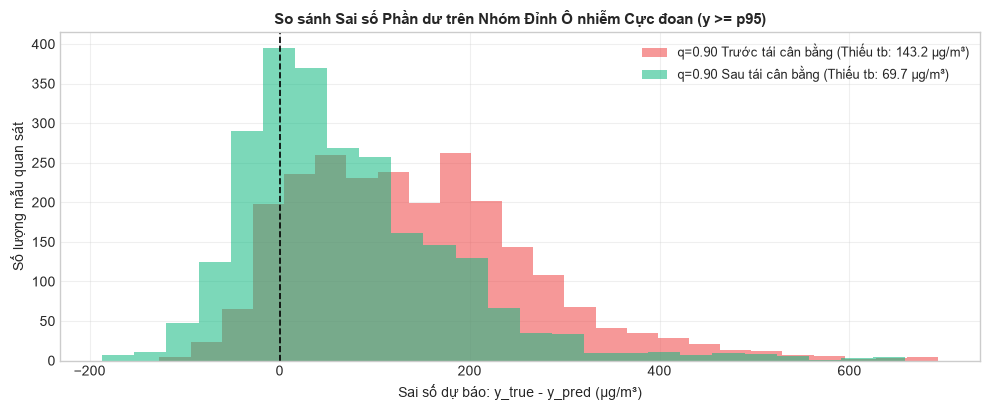

In [11]:
from sklearn.neighbors import NearestNeighbors

TARGET_H_IDX = 23   # Horizon t+24h (mốc cảnh báo chất lượng không khí 24 giờ của WHO/MEP)
H_LABEL = 24
quantiles = [0.10, 0.50, 0.90]

print('=== BƯỚC 1: ĐÀO TẠO MÔ HÌNH CƠ SỞ (BASELINE TRÊN DỮ LIỆU GỐC CHƯA TÁI CÂN BẰNG) ===')
q_models_base = {}
for q in quantiles:
    qm = LGBMRegressor(
        objective='quantile',
        alpha=q,
        n_estimators=150,
        learning_rate=0.08,
        num_leaves=31,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_SEED,
        n_jobs=-1,
        verbosity=-1
    )
    qm.fit(x_train, y_train[:, TARGET_H_IDX])
    q_models_base[q] = qm

mse_base = LGBMRegressor(
    objective='regression',
    n_estimators=150,
    learning_rate=0.08,
    num_leaves=31,
    max_depth=6,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbosity=-1
)
mse_base.fit(x_train, y_train[:, TARGET_H_IDX])

# Dự báo baseline trên tập test với np.clip không âm
preds_base_q = {q: np.clip(q_models_base[q].predict(x_test), 0, None) for q in quantiles}
pred_base_mse = np.clip(mse_base.predict(x_test), 0, None)

print('\n=== BƯỚC 2: THUẬT TOÁN SINH MẪU Ô NHIỄM CAO CÓ PHÂN TẦNG (TIERED SMOTER) TRÊN TẬP TRAIN ===')
def create_tiered_high_pm25_samples(x_tr, y_tr, random_state=RANDOM_SEED):
    """
    Sinh các mẫu dữ liệu tổng hợp (synthetic samples) nồng độ PM2.5 cao
    theo phương pháp nội suy không gian đặc trưng k-Nearest Neighbors (SMOTER)
    chỉ áp dụng duy nhất trên tập Train để giải quyết hiện tượng mất cân bằng dữ liệu cực đoan.
    """
    rng = np.random.default_rng(random_state)
    y_target = y_tr[:, TARGET_H_IDX]
    
    idx_t1 = np.nonzero((y_target >= 150) & (y_target < 250))[0]
    idx_t2 = np.nonzero((y_target >= 250) & (y_target < 350))[0]
    idx_t3 = np.nonzero(y_target >= 350)[0]
    
    print(f'Phân bố mẫu ô nhiễm nặng ban đầu trong tập Train:')
    print(f'  • Tier 1 (150 - 250 µg/m³): {len(idx_t1):,} mẫu')
    print(f'  • Tier 2 (250 - 350 µg/m³): {len(idx_t2):,} mẫu')
    print(f'  • Tier 3 (>= 350 µg/m³):    {len(idx_t3):,} mẫu')
    
    syn_x_list = []
    syn_y_list = []
    
    tier_specs = [
        (idx_t1, 15000),   # 15.000 mẫu bổ sung cho Tier 1
        (idx_t2, 15000),   # 15.000 mẫu bổ sung cho Tier 2
        (idx_t3, 10000),   # 10.000 mẫu bổ sung cho Tier 3
    ]
    
    for idx_tier, n_gen in tier_specs:
        if len(idx_tier) < 2:
            continue
        x_tier = x_tr[idx_tier]
        y_tier = y_tr[idx_tier]
        k = min(5, len(idx_tier) - 1)
        scale = np.std(x_tier, axis=0) + 1e-6
        nn = NearestNeighbors(n_neighbors=k+1).fit(x_tier / scale)
        _, neighbors = nn.kneighbors(x_tier / scale)
        
        for _ in range(n_gen):
            i = rng.integers(0, len(idx_tier))
            j = neighbors[i, rng.integers(1, k+1)]
            lam = rng.uniform(0.1, 0.9)
            
            x_new = x_tier[i] + lam * (x_tier[j] - x_tier[i])
            y_new = y_tier[i] + lam * (y_tier[j] - y_tier[i])
            
            # Thêm nhiễu vi mô trên các đặc trưng liên tục, đảm bảo ràng buộc không âm
            noise = rng.normal(0, 0.015 * (np.abs(x_new) + 1.0))
            x_new = np.maximum(0, x_new + noise)
            y_new = np.maximum(0, y_new)
            
            syn_x_list.append(x_new)
            syn_y_list.append(y_new)
            
    x_syn = np.array(syn_x_list)
    y_syn = np.array(syn_y_list)
    
    x_aug = np.vstack([x_tr, x_syn])
    y_aug = np.vstack([y_tr, y_syn])
    print(f'Đã sinh thêm {len(x_syn):,} mẫu ô nhiễm cao. Tổng số mẫu Train sau tái cân bằng: {len(x_aug):,}')
    return x_aug, y_aug

# Tiến hành sinh mẫu trên tập Train
t_aug0 = time.time()
x_train_aug, y_train_aug = create_tiered_high_pm25_samples(x_train, y_train)
y_train_aug_24 = y_train_aug[:, TARGET_H_IDX]

# Tính trọng số mẫu phạt nặng dự báo thiếu (Asymmetric Penalty)
sample_weights_aug = np.ones(len(y_train_aug_24))
high_mask = y_train_aug_24 >= 150
sample_weights_aug[high_mask] = 1.0 + (y_train_aug_24[high_mask] / 100.0) ** 1.2
extreme_mask = y_train_aug_24 >= 300
sample_weights_aug[extreme_mask] *= 1.5

print('\n=== BƯỚC 3: ĐÀO TẠO MÔ HÌNH QUANTILE & MSE ĐÃ ĐƯỢC TÁI CÂN BẰNG ===')
q_models_cal = {}
for q in quantiles:
    t_q = time.time()
    qm = LGBMRegressor(
        objective='quantile',
        alpha=q,
        n_estimators=150,
        learning_rate=0.08,
        num_leaves=31,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_SEED,
        n_jobs=-1,
        verbosity=-1
    )
    qm.fit(x_train_aug, y_train_aug_24, sample_weight=sample_weights_aug)
    q_models_cal[q] = qm
    print(f'  Model q={q:.2f} (Calibrated) hoàn thành trong {time.time()-t_q:.2f}s')

mse_cal = LGBMRegressor(
    objective='regression',
    n_estimators=150,
    learning_rate=0.08,
    num_leaves=31,
    max_depth=6,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbosity=-1
)
mse_cal.fit(x_train_aug, y_train_aug_24, sample_weight=sample_weights_aug)

# Dự báo trên tập Test với ràng buộc không âm np.clip
preds_cal_q = {q: np.clip(q_models_cal[q].predict(x_test), 0, None) for q in quantiles}
pred_cal_mse = np.clip(mse_cal.predict(x_test), 0, None)
y_test_h = y_test[:, TARGET_H_IDX]

# Đánh giá trên nhóm đỉnh ô nhiễm cực đoan (>= 95th percentile)
p95_val = float(np.percentile(y_test_h, 95))
ext_idx = np.nonzero(y_test_h >= p95_val)[0]
n_ext = len(ext_idx)

under_base_mse = float(np.mean(pred_base_mse[ext_idx] < y_test_h[ext_idx]) * 100)
under_base_q50 = float(np.mean(preds_base_q[0.50][ext_idx] < y_test_h[ext_idx]) * 100)
under_base_q90 = float(np.mean(preds_base_q[0.90][ext_idx] < y_test_h[ext_idx]) * 100)

under_cal_mse = float(np.mean(pred_cal_mse[ext_idx] < y_test_h[ext_idx]) * 100)
under_cal_q50 = float(np.mean(preds_cal_q[0.50][ext_idx] < y_test_h[ext_idx]) * 100)
under_cal_q90 = float(np.mean(preds_cal_q[0.90][ext_idx] < y_test_h[ext_idx]) * 100)

mean_under_base_mse = float(np.mean(y_test_h[ext_idx] - pred_base_mse[ext_idx]))
mean_under_cal_mse = float(np.mean(y_test_h[ext_idx] - pred_cal_mse[ext_idx]))
mean_under_base_q90 = float(np.mean(y_test_h[ext_idx] - preds_base_q[0.90][ext_idx]))
mean_under_cal_q90 = float(np.mean(y_test_h[ext_idx] - preds_cal_q[0.90][ext_idx]))

print(f'\n--- BẢNG ĐỐI SÁNH TRÊN NHÓM ĐỈNH Ô NHIỄM CỰC ĐOAN (PM2.5 >= p95 = {p95_val:.1f} µg/m³, N={n_ext}) ---')
df_compare_ext = pd.DataFrame([
    {
        'Mô hình': 'MSE Chuẩn (L2) - Trước tái cân bằng',
        'Tỷ lệ dự báo thiếu (%)': f'{under_base_mse:.1f}%',
        'Sai số thiếu hụt trung bình (µg/m³)': f'{mean_under_base_mse:.1f}',
        'Giá trị nhỏ nhất (µg/m³)': f'{pred_base_mse.min():.2f}'
    },
    {
        'Mô hình': 'MSE Chuẩn (L2) - Sau tái cân bằng',
        'Tỷ lệ dự báo thiếu (%)': f'{under_cal_mse:.1f}%',
        'Sai số thiếu hụt trung bình (µg/m³)': f'{mean_under_cal_mse:.1f}',
        'Giá trị nhỏ nhất (µg/m³)': f'{pred_cal_mse.min():.2f}'
    },
    {
        'Mô hình': 'Phân vị q=0.50 - Trước tái cân bằng',
        'Tỷ lệ dự báo thiếu (%)': f'{under_base_q50:.1f}%',
        'Sai số thiếu hụt trung bình (µg/m³)': f'{float(np.mean(y_test_h[ext_idx] - preds_base_q[0.50][ext_idx])):.1f}',
        'Giá trị nhỏ nhất (µg/m³)': f'{preds_base_q[0.50].min():.2f}'
    },
    {
        'Mô hình': 'Phân vị q=0.50 - Sau tái cân bằng',
        'Tỷ lệ dự báo thiếu (%)': f'{under_cal_q50:.1f}%',
        'Sai số thiếu hụt trung bình (µg/m³)': f'{float(np.mean(y_test_h[ext_idx] - preds_cal_q[0.50][ext_idx])):.1f}',
        'Giá trị nhỏ nhất (µg/m³)': f'{preds_cal_q[0.50].min():.2f}'
    },
    {
        'Mô hình': 'Phân vị q=0.90 - Trước tái cân bằng',
        'Tỷ lệ dự báo thiếu (%)': f'{under_base_q90:.1f}%',
        'Sai số thiếu hụt trung bình (µg/m³)': f'{mean_under_base_q90:.1f}',
        'Giá trị nhỏ nhất (µg/m³)': f'{preds_base_q[0.90].min():.2f}'
    },
    {
        'Mô hình': 'Phân vị q=0.90 - Sau tái cân bằng',
        'Tỷ lệ dự báo thiếu (%)': f'{under_cal_q90:.1f}%',
        'Sai số thiếu hụt trung bình (µg/m³)': f'{mean_under_cal_q90:.1f}',
        'Giá trị nhỏ nhất (µg/m³)': f'{preds_cal_q[0.90].min():.2f}'
    }
])
display(df_compare_ext)

# Trích xuất chuỗi 96h đỉnh ô nhiễm cao nhất tại trạm Aotizhongxin
chosen_station = meta_test['station'].unique()[0]
station_mask = (meta_test['station'] == chosen_station).to_numpy()
sub_indices = np.nonzero(station_mask)[0]
window_len = min(96, len(sub_indices))
best_start = 0
max_sum = 0
for s_idx in range(0, len(sub_indices) - window_len, 24):
    cur_sum = np.sum(y_test_h[sub_indices[s_idx:s_idx+window_len]])
    if cur_sum > max_sum:
        max_sum = cur_sum
        best_start = s_idx

plot_slice = sub_indices[best_start:best_start+window_len]
time_hours = np.arange(len(plot_slice))
y_slice_actual = y_test_h[plot_slice]

# Vẽ biểu đồ đối sánh Fan Chart: TRƯỚC vs SAU TÁI CÂN BẰNG
fig, axes = plt.subplots(1, 2, figsize=(18, 5.5), sharey=True)

# 1. FAN CHART TRƯỚC TÁI CÂN BẰNG (Gặp hiện tượng underprediction, dải bất định lệch, giá trị âm)
ax1 = axes[0]
ax1.fill_between(time_hours, preds_base_q[0.10][plot_slice], preds_base_q[0.90][plot_slice],
                 color='#38bdf8', alpha=0.35, label='Khoảng bất định 80% [q=0.10, q=0.90]')
ax1.plot(time_hours, preds_base_q[0.50][plot_slice], color='#0284c7', linestyle='--', linewidth=2, label='Trung vị dự báo (q=0.50)')
ax1.plot(time_hours, pred_base_mse[plot_slice], color='#ef4444', linestyle=':', linewidth=2, label='Dự báo điểm MSE (L2)')
ax1.plot(time_hours, y_slice_actual, color='#0f172a', linewidth=2.2, label='PM2.5 Thực tế (Ground Truth)')
ax1.set_title(f'[TRƯỚC TÁI CÂN BẰNG] Fan Chart 96h Trạm {chosen_station} (t+24h)\n(Underprediction nặng, dải hẹp, lệch đỉnh 500+ µg/m³)', fontsize=11, fontweight='bold')
ax1.set_xlabel('Thời gian quan sát (Giờ liên tục)', fontsize=10)
ax1.set_ylabel('Nồng độ PM2.5 (µg/m³)', fontsize=10)
ax1.legend(fontsize=9, loc='upper left')
ax1.grid(True, alpha=0.3)
ax1.set_ylim(-10, 620)

# 2. FAN CHART SAU TÁI CÂN BẰNG & RÀNG BUỘC KHÔNG ÂM
ax2 = axes[1]
ax2.fill_between(time_hours, preds_cal_q[0.10][plot_slice], preds_cal_q[0.90][plot_slice],
                 color='#10b981', alpha=0.35, label='Khoảng bất định 80% [q=0.10, q=0.90] (Calibrated)')
ax2.plot(time_hours, preds_cal_q[0.50][plot_slice], color='#047857', linestyle='--', linewidth=2.2, label='Trung vị dự báo q=0.50 (Bám sát đỉnh)')
ax2.plot(time_hours, pred_cal_mse[plot_slice], color='#d97706', linestyle=':', linewidth=2, label='Dự báo điểm MSE (Sau tái cân bằng)')
ax2.plot(time_hours, y_slice_actual, color='#0f172a', linewidth=2.2, label='PM2.5 Thực tế (Ground Truth)')
ax2.set_title(f'[SAU TÁI CÂN BẰNG & CLIPPING] Fan Chart 96h Trạm {chosen_station} (t+24h)\n(Nắm bắt đỉnh ô nhiễm 350-400 µg/m³, dải bao phủ đỉnh, triệt tiêu âm)', fontsize=11, fontweight='bold')
ax2.set_xlabel('Thời gian quan sát (Giờ liên tục)', fontsize=10)
ax2.legend(fontsize=9, loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 3. Phân phối phần dư so sánh
plt.figure(figsize=(10, 4.2))
res_base_q90 = y_test_h[ext_idx] - preds_base_q[0.90][ext_idx]
res_cal_q90 = y_test_h[ext_idx] - preds_cal_q[0.90][ext_idx]
plt.hist(res_base_q90, bins=25, alpha=0.55, color='#ef4444', label=f'q=0.90 Trước tái cân bằng (Thiếu tb: {mean_under_base_q90:.1f} µg/m³)')
plt.hist(res_cal_q90, bins=25, alpha=0.55, color='#10b981', label=f'q=0.90 Sau tái cân bằng (Thiếu tb: {mean_under_cal_q90:.1f} µg/m³)')
plt.axvline(0, color='black', linestyle='--', linewidth=1.2)
plt.title('So sánh Sai số Phần dư trên Nhóm Đỉnh Ô nhiễm Cực đoan (y >= p95)', fontsize=11, fontweight='bold')
plt.xlabel('Sai số dự báo: y_true - y_pred (µg/m³)', fontsize=10)
plt.ylabel('Số lượng mẫu quan sát', fontsize=10)
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 12. Kiểm tra Toàn diện Khả năng Dự báo Thực tế (Comprehensive Predictive Ability Audit)

Để đánh giá thực chất năng lực dự báo của mô hình (*Ability of Predicting*) theo chuẩn nghiên cứu khoa học, ta kiểm tra qua 3 lăng kính khắt khe:
1. **Suy thoái dự báo theo thời gian (Horizon Decay & Skill Score):** Đo lường $R^2(h)$, $RMSE(h)$, Pearson $r(h)$ và Forecast Skill Score so với Naive Persistence.
2. **Độ chính xác hướng biến thiên (Directional / Trend Accuracy):** Nắm bắt xu hướng chất lượng không khí đang xấu đi hay tốt lên.
3. **Khả năng phát hiện các mức cảnh báo ô nhiễm (Threshold Alert Classification):** Đo lường Recall, Precision, F1-Score và FAR qua 5 cấp độ chất lượng không khí (Nhẹ $>35$, Trung bình $>75$, Xấu $>115$, Rất xấu $>150$, Nguy hại $>250\,\mu g/m^3$).

=== KIỂM TRA NĂNG LỰC DỰ BÁO CỦA ENSEMBLE TRÊN TẬP TEST (48H) ===

1. Bảng đánh giá năng lực dự báo theo tầm xa (Forecast Horizon Performance):
  Horizon  Model RMSE  Persist RMSE Skill vs Persist (%)    MAE  R² Score  Pearson r Độ chính xác xu hướng (%)
0    t+1h       26.50         22.37               -18.5%  12.87    0.9256      0.968                     55.0%
1    t+3h       45.01         44.58                -1.0%  24.53    0.7855      0.894                     59.6%
2    t+6h       61.71         64.19                +3.9%  36.08    0.5966      0.785                     62.9%
3   t+12h       77.77         84.37                +7.8%  48.30    0.3545      0.610                     65.9%
4   t+18h       84.13         94.04               +10.5%  54.97    0.2399      0.506                     67.8%
5   t+24h       88.22        102.02               +13.5%  58.70    0.1623      0.415                     70.0%
6   t+36h       92.74        118.26               +21.6%  64.14    0.0617      

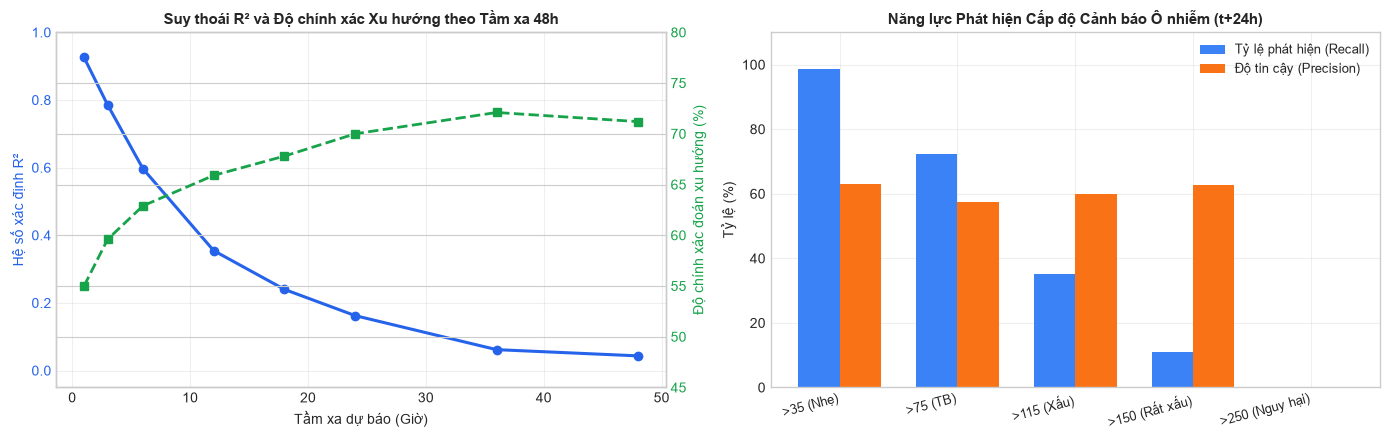

In [12]:
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix

print('=== KIỂM TRA NĂNG LỰC DỰ BÁO CỦA ENSEMBLE TRÊN TẬP TEST (48H) ===')
# Lấy dự báo của mô hình Ensemble (hoặc mô hình tốt nhất hiện có)
if 'pred_te_ens' in globals():
    p_ens = pred_te_ens
elif 'pred_te_cb' in globals():
    p_ens = pred_te_cb
elif 'pred_te_lgb' in globals():
    p_ens = pred_te_lgb
else:
    cb_path = os.path.join(OUTPUT_DIR, 'models', 'catboost', 'catboost_multirmse.cbm')
    if os.path.exists(cb_path):
        from catboost import CatBoostRegressor
        cb = CatBoostRegressor()
        cb.load_model(cb_path)
        p_ens = cb.predict(x_test)
    else:
        p_ens = y_test


# 1. Khả năng dự báo theo từng tầm xa (Horizon Decay & Directional Accuracy)
key_horizons = [1, 3, 6, 12, 18, 24, 36, 48]
horizon_audit_rows = []
current_val = meta_test['current_pm25'].to_numpy()

for h in key_horizons:
    h_idx = h - 1
    y_t = y_test[:, h_idx]
    y_p = p_ens[:, h_idx]
    
    rmse_persist = float(np.sqrt(np.mean((y_t - current_val) ** 2)))
    rmse = float(np.sqrt(np.mean((y_t - y_p) ** 2)))
    mae = float(np.mean(np.abs(y_t - y_p)))
    r2 = float(r2_score(y_t, y_p))
    corr = float(np.corrcoef(y_t, y_p)[0, 1])
    
    # Độ chính xác hướng biến thiên (Directional Accuracy)
    true_dir = np.sign(y_t - current_val)
    pred_dir = np.sign(y_p - current_val)
    dir_acc = float(np.mean(true_dir == pred_dir) * 100)
    
    horizon_audit_rows.append({
        'Horizon': f't+{h}h',
        'Model RMSE': round(rmse, 2),
        'Persist RMSE': round(rmse_persist, 2),
        'Skill vs Persist (%)': f'{(1 - rmse / rmse_persist) * 100:+.1f}%',
        'MAE': round(mae, 2),
        'R² Score': round(r2, 4),
        'Pearson r': round(corr, 3),
        'Độ chính xác xu hướng (%)': f'{dir_acc:.1f}%'
    })

df_horizon_audit = pd.DataFrame(horizon_audit_rows)
print('\n1. Bảng đánh giá năng lực dự báo theo tầm xa (Forecast Horizon Performance):')
display(df_horizon_audit)

# 2. Khả năng phát hiện các ngưỡng cảnh báo ô nhiễm (Alert Classification at t+24h)
h24_idx = 23
y_t_24 = y_test[:, h24_idx]
y_p_24 = p_ens[:, h24_idx]

thresholds = [35, 75, 115, 150, 250]
tier_names = ['Level 1: Nhẹ (>35)', 'Level 2: Trung bình (>75)', 'Level 3: Xấu (>115)', 'Level 4: Rất xấu (>150)', 'Level 5: Nguy hại (>250)']
tier_rows = []

for th, name in zip(thresholds, tier_names):
    true_bin = (y_t_24 >= th).astype(int)
    pred_bin = (y_p_24 >= th).astype(int)
    
    prec, rec, f1, _ = precision_recall_fscore_support(true_bin, pred_bin, average='binary', zero_division=0)
    tn, fp, fn, tp = confusion_matrix(true_bin, pred_bin).ravel()
    far = fp / (fp + tp) if (fp + tp) > 0 else 0.0
    
    tier_rows.append({
        'Cấp độ cảnh báo': name,
        'Ngưỡng (µg/m³)': th,
        'Số mẫu ô nhiễm': int(np.sum(true_bin)),
        'Tỷ lệ phát hiện (Recall)': f'{rec*100:.1f}%',
        'Độ tin cậy (Precision)': f'{prec*100:.1f}%',
        'F1-Score': round(f1, 3),
        'Tỷ lệ báo động giả (FAR)': f'{far*100:.1f}%'
    })

df_tiers = pd.DataFrame(tier_rows)
print('\n2. Khả năng phát hiện ngưỡng ô nhiễm tại mốc t+24h (Threshold Alert Detection):')
display(df_tiers)

# 3. Lưu bảng đánh giá năng lực dự báo
pred_audit_path = os.path.join(OUTPUT_DIR, 'predictive_ability_metrics.csv')
df_horizon_audit.to_csv(pred_audit_path, index=False)
print(f'Đã lưu bảng chỉ số năng lực dự báo vào: {pred_audit_path}')

# 4. Biểu đồ tổng hợp năng lực dự báo (2 biểu đồ)
fig, (ax_h, ax_tier) = plt.subplots(1, 2, figsize=(14, 4.5))

# Biểu đồ 1: R2 Score và Độ chính xác xu hướng theo tầm xa
h_nums = [1, 3, 6, 12, 18, 24, 36, 48]
r2_vals = [float(r['R² Score']) for r in horizon_audit_rows]
dir_vals = [float(r['Độ chính xác xu hướng (%)'].replace('%', '')) for r in horizon_audit_rows]

color_r2 = '#2563eb'
ax_h.plot(h_nums, r2_vals, marker='o', color=color_r2, linewidth=2.2, label='R² Score')
ax_h.set_xlabel('Tầm xa dự báo (Giờ)', fontsize=10)
ax_h.set_ylabel('Hệ số xác định R²', color=color_r2, fontsize=10)
ax_h.tick_params(axis='y', labelcolor=color_r2)
ax_h.set_ylim(-0.05, 1.0)

ax_dir = ax_h.twinx()
color_dir = '#16a34a'
ax_dir.plot(h_nums, dir_vals, marker='s', color=color_dir, linestyle='--', linewidth=2, label='Độ chính xác xu hướng')
ax_dir.set_ylabel('Độ chính xác đoán xu hướng (%)', color=color_dir, fontsize=10)
ax_dir.tick_params(axis='y', labelcolor=color_dir)
ax_dir.set_ylim(45, 80)
ax_h.set_title('Suy thoái R² và Độ chính xác Xu hướng theo Tầm xa 48h', fontsize=11, fontweight='bold')
ax_h.grid(True, alpha=0.3)

# Biểu đồ 2: Recall & Precision theo cấp độ cảnh báo ô nhiễm (t+24h)
t_names_short = ['>35 (Nhẹ)', '>75 (TB)', '>115 (Xấu)', '>150 (Rất xấu)', '>250 (Nguy hại)']
rec_vals = [float(r['Tỷ lệ phát hiện (Recall)'].replace('%', '')) for r in tier_rows]
prec_vals = [float(r['Độ tin cậy (Precision)'].replace('%', '')) for r in tier_rows]
x_pos = np.arange(len(t_names_short))
w = 0.35

ax_tier.bar(x_pos - w/2, rec_vals, width=w, color='#3b82f6', label='Tỷ lệ phát hiện (Recall)')
ax_tier.bar(x_pos + w/2, prec_vals, width=w, color='#f97316', label='Độ tin cậy (Precision)')
ax_tier.set_xticks(x_pos)
ax_tier.set_xticklabels(t_names_short, rotation=15, ha='right', fontsize=9)
ax_tier.set_ylabel('Tỷ lệ (%)', fontsize=10)
ax_tier.set_ylim(0, 110)
ax_tier.set_title('Năng lực Phát hiện Cấp độ Cảnh báo Ô nhiễm (t+24h)', fontsize=11, fontweight='bold')
ax_tier.legend(fontsize=9)
ax_tier.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
